In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.autograd import Function
import operator

import numpy as np
import pickle
import time
import os

from skopt.space import Space
from skopt.sampler import Hammersly
from functools import reduce

from matplotlib import pyplot as plt
import scipy as sp

import copy
from pypower.api import opf, makeYbus, runpf, rundcopf, makeBdc
from pypower import idx_bus, idx_gen, idx_brch, ppoption
from pypower.idx_cost import COST
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
torch.set_default_dtype(torch.float64) # ADD THIS LINE

In [2]:
def config():
    defaults = {}
    defaults['predType'] = ['NN', 'NN_Eq'][1]
    defaults['projType'] = ['WS', 'Proj', 'D_Proj', 'H_Bis'][3]
    defaults['probType'] = ['qp', 'socp', 'convex_qcqp', 'sdp', 'acopf'][4]
    defaults['probSize'] = [[100, 50, 50, 10000],
                            [200, 100, 100, 20000]][1]
    defaults['opfSize'] = [30,  10000] # Adjust this as needed
    defaults['testSize'] = 10
    defaults['saveAllStats'] = False
    defaults['resultsSaveFreq'] = 1000
    defaults['seed'] = 2023

    defaults['mapping_para'] = \
        {'training': True, 'testing': False,
        'n_samples': 1024,
        't_samples': 200,
        'bound': [0, 1],
        'scale_ratio': 1,
        'shape': 'square',
        'total_iteration': 20, 
        'batch_size': 8, # Lowered from 512 for stability
        'num_layer': 3,
        'lr': 1e-4,
        'lr_decay': 0.9,
        'lr_decay_step': 1000,
        'penalty_coefficient': 10,
        'distortion_coefficient': 1,
        'transport_coefficient': 0,
        'testing_samples': 1024}

    defaults['nn_para'] = \
        {'training': True, 'testing': False,
         'approach': 'unsupervise',
        'total_iteration': 100,
        'batch_size': 8, # Lowered from 512 for stability
        'lr': 1e-3,
        'lr_decay': 0.9,
        'lr_decay_step': 1000,
        'num_layer': 3,
        'objWeight': 0.1,
        'softWeightInEqFrac': 10,
        'softWeightEqFrac': 10}

    defaults['proj_para'] = \
        {'useTestCorr': False,    
        'corrMode': 'partial',      
        'corrTestMaxSteps': 100,  
        'corrBis': 0.9,           
        'corrEps': 1e-5,          
        'corrLr': 1e-5,           
        'corrMomentum': 0.1, }    

    return defaults

args = config()
args['probType'] = 'acopf'

In [3]:
def plot_convergence(volume_list, penalty_list, dist_list, trans_list, instance_file):
    index = [i for i in range(len(volume_list))]
    t_num = 3
    fig = plt.figure(figsize=[t_num*(4+1.25),4])
    fig.tight_layout()
    char_size = 20

    plt.subplot(1, t_num, 1)
    plt.plot(index, volume_list, alpha=0.7, c='royalblue', label='Log-det')
    plt.xlabel('Iteration', fontsize=char_size)
    # plt.ylabel('Log-volume', fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.title('Log-volume', fontsize=char_size)

    plt.subplot(1, t_num, 2)
    plt.plot(index, penalty_list, alpha=0.7, c='darkorange', label='Penalty')
    plt.xlabel('Iteration', fontsize=char_size)
    # plt.ylabel('Penalty', fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.title('Constraint violation', fontsize=char_size)

    plt.subplot(1, t_num, 3)
    plt.plot(index, dist_list, alpha=0.7, c='darkred', label='Dist')
    plt.xlabel('Iteration', fontsize=char_size)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    # plt.ylabel('Log-distortion', fontsize=18)
    plt.title('Log-distortion', fontsize=char_size)

    # plt.subplot(1, 4, 4)
    # plt.plot(index, trans_list, alpha=0.7, c='seagreen', label='Dist')
    # plt.xlabel('Iteration', fontsize=15)
    # plt.ylabel('trans_list', fontsize=15)
    # plt.legend(['Transport cost'], fontsize=15)

    # plt.subplots_adjust(wspace=0.15, hspace=0.15)
    plt.subplots_adjust(wspace=0.15)
    plt.savefig(instance_file+'/convergence.png', bbox_inches='tight',  dpi=300)
    # plt.show()
    # plt.close()


In [4]:
def PFFunction(data, tol=1e-5, bsz=1024, max_iters=10):
    class PFFunctionFn(Function):
        @staticmethod
        def forward(ctx, X, Z):
            # start_time = time.time() 
            ## Step 1: Newton's method
            Y = torch.zeros(X.shape[0], data.ydim, device=X.device)
            # known/estimated values (pg at pv buses, vm at all gens, va at slack bus)
            Y[:, data.pg_start_yidx + data.pv_] = Z[:, data.pg_pv_zidx]  # pg at non-slack gens
            Y[:, data.vm_start_yidx + data.spv] = Z[:, data.vm_spv_zidx]  # vm at gens
            # init guesses for remaining values
            Y[:, data.vm_start_yidx + data.pq] = data.vm_init[data.pq]  # vm at load buses
            Y[:, data.va_start_yidx: data.va_start_yidx+data.nb] = data.va_init   # va at all bus
            Y[:, data.qg_start_yidx:data.qg_start_yidx + data.ng] = 0  # qg at gens (not used in Newton upd)
            Y[:, data.pg_start_yidx + data.slack_] = 0  # pg at slack (not used in Newton upd)

            keep_constr = np.concatenate([
                data.pflow_start_eqidx + data.pv,  # real power flow at non-slack gens
                data.pflow_start_eqidx + data.pq,  # real power flow at load buses
                data.qflow_start_eqidx + data.pq])  # reactive power flow at load buses
            newton_guess_inds = np.concatenate([
                data.vm_start_yidx + data.pq,  # vm at load buses
                data.va_start_yidx + data.pv,  # va at non-slack gens
                data.va_start_yidx + data.pq])  # va at load buses

            converged = torch.zeros(X.shape[0])
            jacs = []
            # newton_jacs_inv = []
            for b in range(0, X.shape[0], bsz):
                X_b = X[b:b + bsz]
                Y_b = Y[b:b + bsz]
                for _ in range(max_iters):
                    gy = data.eq_resid(X_b, Y_b)[:, keep_constr]
                    jac_full = data.eq_jac(Y_b)
                    jac = jac_full[:, keep_constr, :]
                    jac = jac[:, :, newton_guess_inds]
                    # start_time = time.time()
                    """Direct inverse"""
                    # newton_jac_inv = torch.inverse(jac)
                    # delta = torch.matmul(newton_jac_inv, gy.unsqueeze(-1)).squeeze(-1)
                    """LU decomposition"""
                    # jac_lu = torch.linalg.lu_factor(jac)
                    # delta = torch.linalg.ldl_solve(jac_lu, gy.unsqueeze(-1)).squeeze(-1)
                    """Linear system"""
                    delta = torch.linalg.solve(jac, gy.unsqueeze(-1)).squeeze(-1)
                    """Approximation"""
                    # delta = 0
                    # tt = torch.eye(jac.shape[-1]).to(jac.device) - 0.01 * jac
                    # jac_inv = gy
                    # for _ in range(5):
                    #     jac_inv = torch.matmul(tt, jac_inv.unsqueeze(-1)).squeeze(-1)
                    #     delta += jac_inv
                    # delta = 0.01 * delta
                    # print('lin run_time', time.time()-start_time)
                    # ineq_step = data.ineq_grad(X_b, Y_b)
                    Y_b[:, newton_guess_inds] -= delta
                    if torch.abs(delta).max() < tol:
                        break
                if torch.abs(delta).max() > tol:
                    print('Newton methods for Power Flow does not converge')
                # print(torch.abs(delta).max())
                converged[b:b + bsz] = (delta.abs() < tol).all(dim=1)
                jacs.append(jac_full)
                # newton_jacs_inv.append(newton_jac_inv)

            ## Step 2: Solve for remaining variables
            # solve for qg values at all gens (note: requires qg in Y to equal 0 at start of computation)
            Y[:, data.qg_start_yidx:data.qg_start_yidx + data.ng] = \
                -data.eq_resid(X, Y)[:, data.qflow_start_eqidx + data.spv]
            # solve for pg at slack bus (note: requires slack pg in Y to equal 0 at start of computation)
            Y[:, data.pg_start_yidx + data.slack_] = \
                -data.eq_resid(X, Y)[:, data.pflow_start_eqidx + data.slack]

            ctx.data = data
            ctx.save_for_backward(torch.cat(jacs),
                                  torch.as_tensor(newton_guess_inds, device=X.device),
                                  torch.as_tensor(keep_constr, device=X.device))
            return Y

        @staticmethod
        def backward(ctx, dl_dy):

            data = ctx.data
            # jac, newton_jac_inv, newton_guess_inds, keep_constr = ctx.saved_tensors
            jac, newton_guess_inds, keep_constr = ctx.saved_tensors

            ## Step 2 (calc pg at slack and qg at gens)
            jac_pre_inv = jac[:, keep_constr, :]
            jac_pre_inv = jac_pre_inv[:, :, newton_guess_inds]

            # gradient of all voltages through step 3 outputs
            last_eqs = np.concatenate([data.pflow_start_eqidx + data.slack, data.qflow_start_eqidx + data.spv])
            last_vars = np.concatenate([
                data.pg_start_yidx + data.slack_, np.arange(data.qg_start_yidx, data.qg_start_yidx + data.ng)])
            jac3 = jac[:, last_eqs, :]
            dl_dvmva_3 = -jac3[:, :, data.vm_start_yidx:].transpose(1, 2).bmm(
                dl_dy[:, last_vars].unsqueeze(-1)).squeeze(-1)

            # gradient of pd at slack and qd at gens through step 3 outputs
            dl_dpdqd_3 = dl_dy[:, last_vars]

            # insert into correct places in x and y loss vectors
            dl_dy_3 = torch.zeros(dl_dy.shape, device=jac.device)
            dl_dy_3[:, data.vm_start_yidx:] = dl_dvmva_3

            dl_dx_3 = torch.zeros(dl_dy.shape[0], data.xdim, device=jac.device)
            dl_dx_3[:, np.concatenate([data.slack, data.nbus + data.spv])] = dl_dpdqd_3

            ## Step 1
            dl_dy_total = dl_dy_3 + dl_dy  # Backward pass vector including result of last step

            # Use precomputed inverse jacobian
            jac2 = jac[:, keep_constr, :]
            # d_int = newton_jac_inv.transpose(1, 2).bmm(dl_dy_total[:, newton_guess_inds].unsqueeze(-1)).squeeze(-1)
            d_int = torch.linalg.solve(jac_pre_inv.transpose(1, 2),
                                       dl_dy_total[:, newton_guess_inds].unsqueeze(-1)).squeeze(-1)

            dl_dz_2 = torch.zeros(dl_dy.shape[0], data.npv + data.ng, device=jac.device)
            dl_dz_2[:, data.pg_pv_zidx] = -d_int[:, :data.npv]  # dl_dpg at pv buses
            dl_dz_2[:, data.vm_spv_zidx] = -jac2[:, :, data.vm_start_yidx + data.spv].transpose(1, 2).bmm(
                d_int.unsqueeze(-1)).squeeze(-1)

            dl_dx_2 = torch.zeros(dl_dy.shape[0], data.xdim, device=jac.device)
            dl_dx_2[:, data.pv] = d_int[:, :data.npv]  # dl_dpd at pv buses
            dl_dx_2[:, data.pq] = d_int[:, data.npv:data.npv + len(data.pq)]  # dl_dpd at pq buses
            dl_dx_2[:, data.nbus + data.pq] = d_int[:, -len(data.pq):]  # dl_dqd at pq buses

            # Final quantities
            dl_dx_total = dl_dx_3 + dl_dx_2
            dl_dz_total = dl_dz_2 + dl_dy_total[:, np.concatenate([
                data.pg_start_yidx + data.pv_, data.vm_start_yidx + data.spv])]
            return dl_dx_total, dl_dz_total
    return PFFunctionFn.apply


In [5]:
def training(model, constraints, optimizer, scheduler, x_tensor, t_tensor, args):
    batch_size = args['batch_size']
    total_iteration = args['total_iteration']
    penalty_coefficient = args['penalty_coefficient']
    distortion_coefficient = args['distortion_coefficient']
    transport_coefficient = args['transport_coefficient']
    volume_list = []
    penalty_list = []
    dist_list = []
    trans_list = []
    bias_tensor = torch.ones(batch_size, x_tensor.shape[1]).to(x_tensor.device) * np.mean(args['bound'])
    model.train()
    for n in range(total_iteration):
        optimizer.zero_grad()
        batch_index = np.random.choice([i for i in range(x_tensor.shape[0])],  batch_size, replace=True)
        x_input = x_tensor[batch_index]
        batch_index = np.random.choice([i for i in range(t_tensor.shape[0])], batch_size, replace=True)
        t_input = t_tensor[batch_index]
        # x_input.requires_grad = True
        n_dim = x_input.shape[1]
        if args['scale_ratio']>1:
            xt, logdet, _ = model(x_input, t_input)
            _, _, logdis = model((x_input-bias_tensor)*args['scale_ratio']+bias_tensor, t_input)
        else:
            xt, logdet, logdis = model(x_input, t_input)
        trans = torch.mean((x_input - xt) ** 2, dim=1, keepdim=True)
        volume = logdet
        xt_scale = constraints.scale(t_input, xt)
        xt_full = constraints.complete_partial(t_input, xt_scale)
        violation = constraints.cal_penalty(t_input, xt_full)
        penalty = torch.sum(torch.abs(violation), dim=-1, keepdim=True)
        loss = -  torch.mean(volume) /n_dim  \
                +  penalty_coefficient * torch.mean(penalty) \
                +  distortion_coefficient * torch.mean(logdis) \
                +  transport_coefficient * torch.mean(trans) 
        loss.backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), 0.01)
        optimizer.step()
        scheduler.step()
        volume_list.append(torch.mean(logdet).detach().cpu().numpy()/n_dim)
        penalty_list.append(torch.mean(penalty).detach().cpu().numpy())
        dist_list.append(torch.mean(logdis).detach().cpu().numpy()/args['num_layer'])
        trans_list.append(torch.mean(trans).detach().cpu().numpy())
        if n%1000==0 and n>0:
            model.eval()
            with torch.no_grad():
            # bias_tensor.requires_grad = True
                x0,_,_ = model(bias_tensor, t_input)
                x0_scale = constraints.scale(t_input, x0)
                x0_full = constraints.complete_partial(t_input, x0_scale, backward=False)
                violation_0 = constraints.check_feasibility(t_input, x0_full)
                penalty_0 = torch.sum(torch.abs(violation_0), dim=-1, keepdim=True)
            print(f'Iteration: {n}/{total_iteration}, '
                  f'Volume: {volume_list[-1]:.4f}, '
                  f'Penalty: {penalty_list[-1]:.4f}, '
                  f'Distortion: {dist_list[-1]:.4f}, '
                  f'Transport: {trans_list[-1]:.4f}, '
                  f'test: {torch.mean(penalty_0).detach().cpu().numpy():.8f}',
                  end='\n')
    return model, volume_list, penalty_list, dist_list, trans_list


In [6]:
def sampling_sphere(n_samples, n_dim):
    dims = []
    for d in range(n_dim):
        dims.append((0., 1.))
    space = Space(dims)
    sampler = Hammersly()
    x = sampler.generate(space.dimensions, n_samples)
    x = np.array(x)

    r = (x[:, [0]]) ** (1 / n_dim)
    # print(r)
    # print(1/0)
    for n in range(1, n_dim):
        if n == 1:
            x[:, n] = x[:, n] * 2 * np.pi
        else:
            x[:, n] = 1 - 2 * x[:, n]
    x_s = []
    for n in range(1, n_dim):
        if n == 1:
            x_s = np.column_stack([np.cos(x[:, n:n + 1]), np.sin(x[:, n:n + 1])])
        else:
            x_s = np.column_stack([np.sqrt(1 - x[:, n:n + 1] ** 2) * x_s, x[:, n:n + 1]])
    return np.multiply(x_s, r)

def sampling_square(n_samples, n_dim):
    dims = []
    for d in range(n_dim):
        dims.append((-1., 1.))
    space = Space(dims)
    sampler = Hammersly()
    x = sampler.generate(space.dimensions, n_samples)
    # x = np.random.uniform(-1,1,[n_samples,n_dim])
    x = np.array(x)
    return x

def sampling_body(n_samples, n_dim, shape, lu=[-1,1]):
    if shape == 'sphere':
        x = sampling_sphere(n_samples, n_dim)
        return x + (lu[0]+lu[1])/2
    elif shape == 'square':
        x = sampling_square(n_samples, n_dim)
        return (x+1)*(lu[1]-lu[0])/2 + lu[0] #x + (lu[0]+lu[1])/2#


In [7]:
class MaskedLinear(nn.Module):
    def __init__(self,
                 in_features,
                 out_features,
                 mask,
                 cond_in_features=None,
                 bias=True):
        super(MaskedLinear, self).__init__()
        self.linear = nn.Linear(in_features, out_features)
        if cond_in_features is not None:
            self.cond_linear = nn.Sequential(nn.Linear(cond_in_features, 2*out_features))
        self.register_buffer('mask', mask)
    def forward(self, inputs, cond_inputs=None):
        output = F.linear(inputs, self.linear.weight * self.mask, self.linear.bias)
        if cond_inputs is not None:
            w, b = self.cond_linear(cond_inputs).chunk(2, 1)
            output = output * w + b
        return output
nn.MaskedLinear = MaskedLinear


def get_mask(in_features, out_features, in_flow_features, mask_type=None):
    """
    mask_type: input | None | output

    See Figure 1 for a better illustration:
    https://arxiv.org/pdf/1502.03509.pdf
    """
    if mask_type == 'input':
        in_degrees = torch.arange(in_features) % in_flow_features
    else:
        in_degrees = torch.arange(in_features) % (in_flow_features - 1)

    if mask_type == 'output':
        out_degrees = torch.arange(out_features) % in_flow_features - 1
    else:
        out_degrees = torch.arange(out_features) % (in_flow_features - 1)

    return (out_degrees.unsqueeze(-1) >= in_degrees.unsqueeze(0))


In [8]:
class ActNorm(nn.Module):
    """ An implementation of a activation normalization layer
    from Glow: Generative Flow with Invertible 1x1 Convolutions
    (https://arxiv.org/abs/1807.03039).
    """
    def __init__(self, num_inputs):
        super(ActNorm, self).__init__()
        self.weight = nn.Parameter(torch.ones(num_inputs))
        self.bias = nn.Parameter(torch.zeros(num_inputs))
        self.initialized = False

    def forward(self, inputs, cond_inputs=None, mode='direct'):
        if self.initialized == False:
            self.weight.data.copy_(torch.log(1.0 / (inputs.std(0) + 1e-12)))
            self.bias.data.copy_(inputs.mean(0))
            self.initialized = True

        if mode == 'direct':
            return (inputs - self.bias) * torch.exp(self.weight), self.weight.unsqueeze(0).repeat(inputs.size(0), 1)
        else:
            return inputs * torch.exp( -self.weight) + self.bias, -self.weight.unsqueeze(0).repeat(inputs.size(0), 1)

class LUInvertibleMM(nn.Module):
    """ An implementation of a invertible matrix multiplication
    layer from Glow: Generative Flow with Invertible 1x1 Convolutions
    (https://arxiv.org/abs/1807.03039).
    """

    def __init__(self, num_inputs):
        super(LUInvertibleMM, self).__init__()
        self.W = torch.Tensor(num_inputs, num_inputs)
        nn.init.orthogonal_(self.W)
        self.L_mask = torch.tril(torch.ones(self.W.size()), -1)
        self.U_mask = self.L_mask.t().clone()

        P, L, U = sp.linalg.lu(self.W.numpy())
        self.P = torch.tensor(P)
        self.L = nn.Parameter(torch.tensor(L))
        self.U = nn.Parameter(torch.tensor(U))

        S = np.diag(U)
        sign_S = np.sign(S)
        log_S = np.log(abs(S))
        self.sign_S = torch.tensor(sign_S)
        self.log_S = nn.Parameter(torch.tensor(log_S))

        self.I = torch.eye(self.L.size(0))

    def forward(self, inputs, cond_inputs=None, mode='direct'):
        if str(self.L_mask.device) != str(self.L.device):
            self.L_mask = self.L_mask.to(self.L.device)
            self.U_mask = self.U_mask.to(self.L.device)
            self.I = self.I.to(self.L.device)
            self.P = self.P.to(self.L.device)
            self.sign_S = self.sign_S.to(self.L.device)

        L = self.L * self.L_mask + self.I
        U = self.U * self.U_mask + torch.diag(
            self.sign_S * torch.exp(self.log_S))

        W = self.P @ L @ U


        if mode == 'direct':
            return inputs @ W, self.log_S.unsqueeze(
                0).repeat(inputs.size(0), 1)
        else:
            return inputs @ torch.inverse(
                W), -self.log_S.unsqueeze(0).repeat(
                    inputs.size(0), 1)

class MADE(nn.Module):
    """ An implementation of MADE
    (https://arxiv.org/abs/1502.03509).
    """
    def __init__(self,
                 num_inputs,
                 num_hidden,
                 num_cond_inputs=None,
                 act='relu',
                 pre_exp_tanh=False):
        super(MADE, self).__init__()

        activations = {'relu': nn.ReLU, 'sigmoid': nn.Sigmoid, 'tanh': nn.Tanh}
        act_func = activations[act]

        input_mask = get_mask(num_inputs, num_hidden, num_inputs, mask_type='input')
        hidden_mask = get_mask(num_hidden, num_hidden, num_inputs)
        output_mask = get_mask(num_hidden, num_inputs * 2, num_inputs, mask_type='output')
        self.joiner = nn.MaskedLinear(num_inputs, num_hidden, input_mask, num_cond_inputs)
        self.trunk = nn.Sequential(act_func(), nn.MaskedLinear(num_hidden, num_hidden, hidden_mask),
                                   act_func(), nn.MaskedLinear(num_hidden, num_inputs * 2, output_mask))

    def forward(self, inputs, cond_inputs=None, mode='direct'):
        if mode == 'direct':
            h = self.joiner(inputs, cond_inputs)
            m, a = self.trunk(h).chunk(2, 1)
            u = (inputs - m) * torch.exp(-a)
            return u, -a
        else:
            x = torch.zeros_like(inputs)
            for i_col in range(inputs.shape[1]):
                h = self.joiner(x, cond_inputs)
                m, a = self.trunk(h).chunk(2, 1)
                x[:, i_col] = inputs[:, i_col] * torch.exp(a[:, i_col]) + m[:, i_col]
            return x, -a

class Sigmoid(nn.Module):
    def __init__(self):
        super(Sigmoid, self).__init__()
        self.lower = -0.1
        self.upper = 1.1

    def forward(self, inputs, cond_inputs=None, mode='direct'):
        if mode == 'direct':
            y = torch.sigmoid(inputs)
            scale_y =  y * (self.upper-self.lower) + self.lower
            return scale_y, torch.log(y * (1 - y) * (self.upper-self.lower))
        else:
            x = (inputs - self.lower)/(self.upper-self.lower)
            return torch.log(x / (1 - x)), -torch.log((inputs - inputs**2)/(self.upper-self.lower))

class INN(nn.Module):
    """ A sequence of invertible layers """
    def __init__(self, flows, con_emb=None):
        super().__init__()
        self.flows = nn.ModuleList(flows)
        self.con_emb = con_emb

    def forward(self, x, t):
        m, _ = x.shape
        log_det = torch.zeros(m).to(x.device)
        log_dis = torch.zeros(m).to(x.device)
        if self.con_emb is not None:
            t = self.con_emb(t)
        for flow in self.flows:
            x, ls = flow.forward(x, t)
            ld = ls.sum(-1)
            dis = torch.max(ls,-1)[0] - torch.min(ls,-1)[0]
            log_det += ld.view(-1)
            log_dis += dis.view(-1)
        return x, log_det, log_dis

    def forward_traj(self, x, t):
        m, _ = x.shape
        x_list = []
        if self.con_emb is not None:
            t = self.con_emb(t)
        for flow in self.flows:
            x, ls = flow.forward(x, t)
            x_list.append(x)
        return x_list

    def backward(self, z, t):
        if self.con_emb is not None:
            t = self.con_emb(t)
        for flow in self.flows[::-1]:
            z, _ = flow.forward(z, t, mode='inverse')
        return z, None, None


In [9]:
def dict_agg(stats, key, value, op='concat'):
    if key in stats.keys():
        if op == 'sum':
            stats[key] += value
        elif op == 'concat':
            stats[key] = np.concatenate((stats[key], value), axis=0)
        else:
            raise NotImplementedError
    else:
        stats[key] = value


class NNSolver(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim, args):
        super().__init__()
        self._args = args
        layer_sizes = [in_dim]+ [hidden_dim] * self._args['nn_para']['num_layer']
        layers = reduce(operator.add,
                        [[nn.Linear(a, b), nn.ReLU()]
                         for a, b in zip(layer_sizes[0:-1], layer_sizes[1:])])
        layers += [nn.Linear(layer_sizes[-1], out_dim), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = self.net(x)
        return x


def train_mdh_mapping(data, args, save_dir):
    paras = args['mapping_para']
    ### input pparameters --> output solutions
    t_tensor = data.X.squeeze()
    x_tensor = data.Y[:, data.partial_unknown_vars].squeeze()
    t_samples, t_dim = t_tensor.shape
    n_samples, n_dim = x_tensor.shape
    #### Flow-based model: ball -> constraint set
    mask = torch.zeros(size=[1,n_dim], device=DEVICE)
    mask[:, :n_dim//2] = 1
    num_layer = paras['num_layer']
    flow_modules = []
    for _ in range(num_layer):
        flow_modules += [ActNorm(num_inputs=n_dim),
                         LUInvertibleMM(num_inputs=n_dim),
                         ActNorm(num_inputs=n_dim),
                         MADE(num_inputs=n_dim, num_hidden=n_dim//2, num_cond_inputs=t_dim)]
                                #  CouplingLayer(n_dim, n_dim//2, mask, t_dim)]
    flow_modules += [ActNorm(num_inputs=n_dim), Sigmoid()]
    model = INN(flow_modules, None).to(device=DEVICE)
    optimizer = optim.Adam(model.parameters(),
                           lr=paras['lr'],
                           weight_decay=1e-6)
    scheduler = optim.lr_scheduler.StepLR(optimizer,
                                          step_size=paras['lr_decay_step'],
                                          gamma=paras['lr_decay'])
    #### Sampling input parameters and output decision
    initial_shape = paras['shape']
    bound = paras['bound']  # initial shape to [0,1] bounded constraint set
    x_train = sampling_body(paras['n_samples'], n_dim, initial_shape, lu=bound)
    x_train_tensor = torch.tensor(x_train).view(-1, n_dim).to(device=DEVICE)
    t_train_tensor = torch.rand([paras['t_samples'], t_dim]).to(device=DEVICE)
    t_train_tensor = t_train_tensor * (data.input_U - data.input_L) + data.input_L

    #### Unsupervised Training for Homeo Mapping  
    model, volume_list, penalty_list, dist_list, trans_list = training(model, data, 
                                                                       optimizer, scheduler,
                                                                       x_train_tensor, t_train_tensor, 
                                                                       paras)
    plot_convergence(volume_list, penalty_list, dist_list, trans_list, save_dir)
    torch.save(model, os.path.join(save_dir, 'mapping.pth'))

def train_nn_solver(data, args, save_dir):
    lr = args['nn_para']['lr']
    nepochs = args['nn_para']['total_iteration']
    batch_size = args['nn_para']['batch_size']
    lr_decay = args['nn_para']['lr_decay']
    lr_decay_step = args['nn_para']['lr_decay_step']
    training_appoach = args['nn_para']['approach']
    ## Run pure optimization baselines
    # if args['probType'] == 'acopf':
    #     solvers = ['pypower']
    # else:
    #     solvers = ['cvxpy']  # 'qpth osqp'
    # _, _, opt_time = data.opt_solve(data.testX[:2], solver_type=solvers[0], tol=args['proj_para']['corrEps'])
    # print(f'full paralell pure opt time {opt_time}')
    # print('solution range', torch.max(data.trainY), torch.min(data.trainY))

    ### Equality completion
    if 'Eq' in args['algoType']:
        out_dim = len(data.partial_unknown_vars)
    ### Direct
    else:
        out_dim = data.testY.shape[1]

    in_dim = data.xdim
    hidden_dim = (in_dim + out_dim) // 2
    solver_net = NNSolver(data.xdim, out_dim, hidden_dim, args)
    solver_net.to(DEVICE)
    solver_opt = optim.Adam(solver_net.parameters(), lr=lr, weight_decay=1e-5)
    solver_shce = optim.lr_scheduler.StepLR(solver_opt, step_size=lr_decay_step, gamma=lr_decay)
    try:
        homeo_mapping = torch.load(os.path.join(save_dir, 'mapping.pth'), map_location=DEVICE, weights_only=False)
    except:
        homeo_mapping = None
    stats = {}
    solver_net.train()

    Xtrain = data.trainX.to(DEVICE)
    Ytrain = data.trainY.squeeze().to(DEVICE)
    Xtest = data.testX.to(DEVICE)
    Ytest = data.testY.squeeze().to(DEVICE)

    for i in range(nepochs + 1):
        epoch_stats = {}
        if training_appoach == 'supervise':
            batch_index = np.random.choice(np.arange(Xtrain.shape[0]), batch_size, replace=True)
            # Get train loss
            Xtrain_batch = Xtrain[batch_index]
            Ytrain_batch = Ytrain[batch_index]
            start_time = time.time()
            Y_pred_batch = solver_net(Xtrain_batch)
            Y_pred_scale_batch = data.scale(Xtrain_batch, Y_pred_batch)
            if 'Eq' in args['algoType']:
                Y_pred_scale_batch = data.complete_partial(Xtrain_batch, Y_pred_scale_batch)
            training_obj = data.obj_fn(Y_pred_scale_batch)
            real_obj = data.obj_fn(Ytrain_batch)
            eq_penalty = torch.sum(torch.abs(data.eq_resid(Xtrain_batch, Y_pred_scale_batch)), dim=1)
            ineq_penalty = torch.sum(torch.abs(data.ineq_resid(Xtrain_batch, Y_pred_scale_batch)), dim=1)
            mse_loss = nn.MSELoss(reduction='none')(Y_pred_scale_batch, Ytrain_batch).sum(dim=1)
            train_loss = mse_loss \
                        + args['nn_para']['softWeightInEqFrac'] * ineq_penalty \
                        + args['nn_para']['softWeightEqFrac'] * eq_penalty \
                        + args['nn_para']['objWeight'] * training_obj
        else:
            Xtrain_batch = torch.rand([batch_size, Xtest.shape[1]]).to(device=DEVICE)
            Xtrain_batch = Xtrain_batch * (data.input_U - data.input_L) + data.input_L
            start_time = time.time()
            Y_pred_batch = solver_net(Xtrain_batch)
            Y_pred_scale_batch = data.scale(Xtrain_batch, Y_pred_batch)
            if 'Eq' in args['algoType']:
                Y_pred_scale_batch = data.complete_partial(Xtrain_batch, Y_pred_scale_batch)
            training_obj = data.obj_fn(Y_pred_scale_batch)
            eq_penalty = torch.sum(torch.abs(data.eq_resid(Xtrain_batch, Y_pred_scale_batch)), dim=1)
            ineq_penalty = torch.sum(torch.abs(data.ineq_resid(Xtrain_batch, Y_pred_scale_batch)), dim=1)
            train_loss = args['nn_para']['softWeightInEqFrac'] * ineq_penalty \
                        + args['nn_para']['softWeightEqFrac'] * eq_penalty \
                        + args['nn_para']['objWeight'] * training_obj

        train_loss.mean().backward()
        solver_opt.step()
        solver_shce.step()
        solver_opt.zero_grad()
        train_time = time.time() - start_time
        dict_agg(epoch_stats, 'train_loss', train_loss.detach().cpu().numpy())
        dict_agg(epoch_stats, 'train_obj', training_obj.detach().cpu().numpy())
        # dict_agg(epoch_stats, 'train_real_obj', real_obj.detach().cpu().numpy())
        dict_agg(epoch_stats, 'train_time', train_time, op='sum')

        # Print results
        if i % args['resultsSaveFreq'] == 0 and i > 0:
            solver_net.eval()
            with torch.no_grad():
                eval_solution(data, Xtest, Ytest, solver_net, homeo_mapping, args, 'test', epoch_stats)
            print('Epoch:{}\n'
                  'Raw_loss: MSE({:.4f}), MAE({:.4f}), MAP({:.4f}),     Raw_obj: MSE({:.4f}), MAE({:.4f}), MAP({:.4f}) \n'
                  'Raw_Ineq: Max({:.4f}), Sum({:.4f}), Per({:.4f}),     Raw_eq:  Max({:.4f}), Sum({:.4f}), Per({:.4f})\n'.format(
                i,
                np.mean(epoch_stats['test_raw_mse_loss']), np.mean(epoch_stats['test_raw_mae_loss']),
                np.mean(epoch_stats['test_raw_mape_loss']), np.mean(epoch_stats['test_raw_obj_mse']),
                np.mean(epoch_stats['test_raw_obj_mae']), np.mean(epoch_stats['test_raw_obj_mape']),
                np.mean(epoch_stats['test_raw_ineq_max']), np.mean(epoch_stats['test_raw_ineq_sum']),
                np.mean(epoch_stats['test_raw_ineq_num_viol_0']) / data.nineq,
                np.mean(epoch_stats['test_raw_eq_max']),
                np.mean(epoch_stats['test_raw_eq_sum']), np.mean(epoch_stats['test_raw_eq_num_viol_0']) / data.neq))
            with open(os.path.join(save_dir, 'solver_net.pth'), 'wb') as f:
                torch.save(solver_net, f)
        if args['saveAllStats']:
            if i == 0:
                for key in epoch_stats.keys():
                    stats[key] = np.expand_dims(np.array(epoch_stats[key]), axis=0)
            else:
                for key in epoch_stats.keys():
                    stats[key] = np.concatenate((stats[key], np.expand_dims(np.array(epoch_stats[key]), axis=0)))
        else:
            stats = epoch_stats
    with open(os.path.join(save_dir, 'train_stats.dict'), 'wb') as f:
        pickle.dump(stats, f)
    return solver_net, stats


In [10]:
class ACOPFProblem:
    """
        minimize_{p_g, q_g, vmag, vang} p_g^T A p_g + b p_g + c
        s.t.                  p_g min   <= p_g  <= p_g max
                              q_g min   <= q_g  <= q_g max
                              vmag min  <= vmag <= vmag max
                              vang_slack = \theta_slack   # voltage angle
                              va_ij min <= va_ij <= va_ij max
                              s_ij <= s_ij max
                              (p_g - p_d) + (q_g - q_d)i = diag(vmag e^{i*vang}) conj(Y) (vmag e^{-i*vang})
    """
    def __init__(self, data, test_size):
        ## Define optimization problem input and output variables
        ppc = data['ppc']
        self.ppc = ppc
        self.genbase = ppc['gen'][:, idx_gen.MBASE]
        self.baseMVA = ppc['baseMVA']
        demand = data['Dem'] / self.baseMVA
        gen = data['Gen'] / self.genbase
        voltage = data['Vol']
        self.nbus = voltage.shape[1]
        self.slack = np.where(ppc['bus'][:, idx_bus.BUS_TYPE] == 3)[0]
        self.pv = np.where(ppc['bus'][:, idx_bus.BUS_TYPE] == 2)[0]
        self.spv = np.concatenate([self.slack, self.pv])
        self.spv.sort()
        self.pq = np.setdiff1d(range(self.nbus), self.spv)
        self.nonslack_idxes = np.sort(np.concatenate([self.pq, self.pv]))
        self.branch_idxes = np.concatenate([[ppc['branch'][:, idx_brch.F_BUS]], 
                                            [ppc['branch'][:, idx_brch.T_BUS]]], axis=0).T - 1
        # pv: generators wihtout slack
        # spv: generators with slack bus (slack bus with known vol angle)
        # pq: load bus (zero Pg Qg generation)
        # ng = len(spv), npv = len(pv), nslack = len(slack), nbus = ng + len(pq)
        # indices within generator
        self.slack_ = np.array([np.where(x == self.spv)[0][0] for x in self.slack])
        self.pv_ = np.array([np.where(x == self.spv)[0][0] for x in self.pv])

        self.ng = ppc['gen'].shape[0]
        self.nb = ppc['bus'].shape[0]
        self.nslack = len(self.slack)
        self.npv = len(self.pv)

        self.quad_costs = torch.tensor(ppc['gencost'][:, 4] )
        self.lin_costs = torch.tensor(ppc['gencost'][:, 5] )
        self.const_cost = ppc['gencost'][:, 6].sum()

        # initial values for solver
        self.pg_init = torch.tensor(ppc['gen'][:, idx_gen.PG] / self.genbase)
        self.qg_init = torch.tensor(ppc['gen'][:, idx_gen.QG] / self.genbase)
        self.vm_init = torch.tensor(ppc['bus'][:, idx_bus.VM])
        self.va_init = torch.tensor(np.deg2rad(ppc['bus'][:, idx_bus.VA]))
        # upper and lower bound
        self.pmax = torch.tensor(ppc['gen'][:, idx_gen.PMAX] / self.genbase )
        self.pmin = torch.tensor(ppc['gen'][:, idx_gen.PMIN] / self.genbase )
        self.qmax = torch.tensor(ppc['gen'][:, idx_gen.QMAX] / self.genbase )
        self.qmin = torch.tensor(ppc['gen'][:, idx_gen.QMIN] / self.genbase )
        self.vmax = torch.tensor(ppc['bus'][:, idx_bus.VMAX] )
        self.vmin = torch.tensor(ppc['bus'][:, idx_bus.VMIN] )
        self.smax = torch.tensor(ppc['branch'][:, idx_brch.RATE_A] / self.baseMVA) 
        self.amax = torch.tensor(np.deg2rad(ppc['branch'][:, idx_brch.ANGMAX])) 
        self.amin = torch.tensor(np.deg2rad(ppc['branch'][:, idx_brch.ANGMIN]))
        self.slackva = self.va_init[self.slack]
        # torch.tensor(np.array([np.deg2rad(ppc['bus'][self.slack, idx_bus.VA])])).squeeze(-1)


        ppc2 = copy.deepcopy(ppc)
        ppc2['bus'][:, 0] -= 1
        ppc2['branch'][:, [0, 1]] -= 1
        ppc2['branch'] = ppc2['branch'][:, 1:]
        Ybus, _, _ = makeYbus(self.baseMVA, ppc2['bus'], ppc2['branch'])
        Ybus = Ybus.todense()
        self.Ybusr = torch.tensor(np.real(Ybus) )
        self.Ybusi = torch.tensor(np.imag(Ybus) )

        # indices of useful quantities in full solution
        self.pg_start_yidx = 0
        self.qg_start_yidx = self.ng
        self.vm_start_yidx = 2 * self.ng
        self.va_start_yidx = 2 * self.ng + self.nbus

        ## Keep parameters indicating how data was generated
        self.EPS_INTERIOR = data['EPS_INTERIOR'][0][0]
        self.CorrCoeff = data['CorrCoeff'][0][0]
        self.MaxChangeLoad = data['MaxChangeLoad'][0][0]
        base_load = torch.tensor(np.concatenate([ppc['bus'][:, idx_bus.PD],
                                                 ppc['bus'][:, idx_bus.QD]],axis=0)) / self.baseMVA
        self.input_L = base_load * (1-self.MaxChangeLoad)
        self.input_U = base_load * (1+self.MaxChangeLoad)

        ## Define train/valid/test split
        # self.valid_frac = valid_frac
        # self.test_frac = test_frac 

        ### Load data
        X = np.concatenate([np.real(demand), np.imag(demand)], axis=1)
        Y = np.concatenate([np.real(gen), np.imag(gen), 
                            np.abs(voltage), np.angle(voltage)], axis=1)
        feas_mask = ~np.isnan(Y).any(axis=1)
        self.X = torch.tensor(X[feas_mask] )
        self.Y = torch.tensor(Y[feas_mask] )
        self.xdim = X.shape[1]
        self.ydim = Y.shape[1]
        self.num = feas_mask.sum()
        self.neq = 2 * self.nbus
        self.nineq = 4 * self.ng + 2 * self.nbus
        self.nknowns = self.nslack
        # print(self.neq, self.nineq, self.ydim, self.xdim)

        self.trainX = self.X[:-test_size]
        self.testX = self.X[-test_size:]
        self.trainY = self.Y[:-test_size]
        self.testY = self.Y[-test_size:]


        ## Define variables and indices for "partial completion" neural network
        # pg (non-slack) and |v|_g (including slack)
        self.partial_vars = np.concatenate([self.pg_start_yidx + self.pv_, 
                                            self.vm_start_yidx + self.spv, 
                                            self.va_start_yidx + self.slack])
        self.other_vars = np.setdiff1d(np.arange(self.ydim), self.partial_vars)
        self.partial_unknown_vars = np.concatenate([self.pg_start_yidx + self.pv_, 
                                                    self.vm_start_yidx + self.spv])

        # indices of useful quantities in partial solution
        self.pg_pv_zidx = np.arange(self.npv)
        self.vm_spv_zidx = np.arange(self.npv, 2 * self.npv + self.nslack)
        # useful indices for equality constraints
        self.pflow_start_eqidx = 0
        self.qflow_start_eqidx = self.nbus

        ### For Pytorch
        self.device = DEVICE



    def __str__(self):
        return 'ACOPF-{}-{}-{}-{}-{}-{}'.format(
            self.nbus, self.EPS_INTERIOR, self.CorrCoeff, self.MaxChangeLoad,  0.2, 0.0)

    def get_yvars(self, Y):
        pg = Y[:, :self.ng]
        qg = Y[:, self.ng:2 * self.ng]
        vm = Y[:, -2 * self.nbus:-self.nbus]
        va = Y[:, -self.nbus:]
        return pg, qg, vm, va

    def obj_fn(self, Y):
        pg, _, _, _ = self.get_yvars(Y)
        pg_mw = pg * torch.tensor(self.genbase ).to(Y.device)
        cost = (self.quad_costs * pg_mw ** 2).sum(axis=1) + \
               (self.lin_costs * pg_mw).sum(axis=1) + \
               self.const_cost
        return cost / (self.genbase.mean() ** 2)

    def eq_resid(self, X, Y):
        pg, qg, vm, va = self.get_yvars(Y)

        vr = vm * torch.cos(va)
        vi = vm * torch.sin(va)

        ## power balance equations
        tmp1 = vr @ self.Ybusr - vi @ self.Ybusi
        tmp2 = -vr @ self.Ybusi - vi @ self.Ybusr

        # real power
        pg_expand = torch.zeros(pg.shape[0], self.nbus, device=X.device)
        pg_expand[:, self.spv] = pg
        real_resid = (pg_expand - X[:, :self.nbus]) - (vr * tmp1 - vi * tmp2)

        # reactive power
        qg_expand = torch.zeros(qg.shape[0], self.nbus, device=X.device)
        qg_expand[:, self.spv] = qg
        react_resid = (qg_expand - X[:, self.nbus:]) - (vr * tmp2 + vi * tmp1)

        ## all residuals
        resids = torch.cat([
            real_resid,
            react_resid
        ], dim=1)

        return resids

    def ineq_resid(self, X, Y):
        pg, qg, vm, va = self.get_yvars(Y)
        ## Bus llimit
        resids = torch.cat([
            pg - self.pmax,
            self.pmin - pg,
            qg - self.qmax,
            self.qmin - qg,
            vm - self.vmax,
            self.vmin - vm,
            # self.branch_ineq_resid(X, Y)
        ], dim=1)
        return torch.clamp(resids, 0)

    def branch_ineq_resid(self, X, Y):
        _, _, vm, va = self.get_yvars(Y)
        ### Branch angele limit
        vaij = va.view(-1,self.nbus,1) - va.view(-1,1,self.nbus)
        branch_a = vaij[:,self.branch_idxes[:,0], self.branch_idxes[:,1]]
        resids_brach_angle = torch.cat([branch_a - self.amax, 
                                  self.amin - branch_a], dim=1)
        
        ### Branch flow limit
        vmij = vm.view(-1,self.nbus,1) * vm.view(-1,1,self.nbus)
        vmii = vm.view(-1,self.nbus,1) ** 2
        sin_vaij = torch.sin(vaij)
        cos_vaij = torch.cos(vaij)
        pij = (
            self.Ybusr.view(-1,self.nbus,self.nbus) * vmii -  \
            vmij * (self.Ybusi.view(-1,self.nbus,self.nbus)*sin_vaij + \
            self.Ybusr.view(-1,self.nbus,self.nbus)*cos_vaij)
            )[:,self.branch_idxes[:,0], self.branch_idxes[:,1]]
        qij = (
            - self.Ybusi.view(-1,self.nbus,self.nbus) * vmii -  \
            vmij * (self.Ybusr.view(-1,self.nbus,self.nbus)*sin_vaij - \
            self.Ybusi.view(-1,self.nbus,self.nbus)*cos_vaij)
            )[:,self.branch_idxes[:,0], self.branch_idxes[:,1]]
        sij = torch.sqrt(pij**2 + qij**2)
        resids_brach_flow = sij - self.smax 
        # print(sij, self.smax ** 2)
        # print(1/0)
        return torch.clamp(torch.cat([resids_brach_angle, resids_brach_flow], dim=1), 0)

    def eq_grad(self, X, Y):
        eq_jac = self.eq_jac(Y)
        eq_resid = self.eq_resid(X, Y)
        return 2 * eq_jac.transpose(1, 2).bmm(eq_resid.unsqueeze(-1)).squeeze(-1)

    def ineq_grad(self, X, Y, mode='unfold'):
        if mode == 'unfold':
            ineq_jac = self.ineq_jac(Y)
            ineq_resid = self.ineq_resid(X, Y)
            return 2 * ineq_jac.transpose(1, 2).bmm(ineq_resid.unsqueeze(-1)).squeeze(-1)
        elif mode == 'autograd':
            grad_list = []
            for n in range(Y.shape[0]):
                x = X[n].view(1, -1)
                y = Y[n].view(1, -1)
                y = torch.autograd.Variable(y, requires_grad=True)
                ineq_penalty = self.ineq_resid(x, y) ** 2
                ineq_penalty = torch.sum(ineq_penalty, dim=-1, keepdim=True)
                grad = torch.autograd.grad(ineq_penalty, y)[0]
                grad_list.append(grad.view(1, -1))
            grad = torch.cat(grad_list, dim=0)
            return grad        

    def ineq_partial_grad(self, X, Y):
        eq_jac = self.eq_jac(Y)
        dynz_dz = -torch.inverse(eq_jac[:, :, self.other_vars]).bmm(eq_jac[:, :, self.partial_vars])

        direct_grad = self.ineq_grad(X, Y)
        indirect_partial_grad = dynz_dz.transpose(1, 2).bmm(
            direct_grad[:, self.other_vars].unsqueeze(-1)).squeeze(-1)

        full_partial_grad = indirect_partial_grad + direct_grad[:, self.partial_vars]

        full_grad = torch.zeros(X.shape[0], self.ydim, device=X.device)
        full_grad[:, self.partial_vars] = full_partial_grad
        full_grad[:, self.other_vars] = dynz_dz.bmm(full_partial_grad.unsqueeze(-1)).squeeze(-1)

        return full_grad

    def eq_jac(self, Y):
        _, _, vm, va = self.get_yvars(Y)
        # helper functions
        mdiag = lambda v1, v2: torch.diag_embed(
            torch.multiply(v1, v2))  # torch.diag_embed(v1).bmm(torch.diag_embed(v2))
        Ydiagv = lambda Y, v: torch.multiply(Y.unsqueeze(0), v.unsqueeze(
            1))  # Y.unsqueeze(0).expand(v.shape[0], *Y.shape).bmm(torch.diag_embed(v))
        dtm = lambda v, M: torch.multiply(v.unsqueeze(2), M)  # torch.diag_embed(v).bmm(M)

        # helper quantities
        cosva = torch.cos(va)
        sinva = torch.sin(va)
        vr = vm * torch.cos(va)
        vi = vm * torch.sin(va)
        Yr = self.Ybusr
        Yi = self.Ybusi
        YrvrYivi = vr @ Yr - vi @ Yi
        YivrYrvi = vr @ Yi + vi @ Yr
        # print(cosva.shape, YrvrYivi.shape, Yi.shape, Ydiagv(Yr, -vi).shape)
        # print(1/0)
        # real power equations
        dreal_dpg = torch.zeros(self.nbus, self.ng, device=Y.device)
        dreal_dpg[self.spv, :] = torch.eye(self.ng, device=Y.device)
        dreal_dvm = -mdiag(cosva, YrvrYivi) - dtm(vr, Ydiagv(Yr, cosva) - Ydiagv(Yi, sinva)) \
                    - mdiag(sinva, YivrYrvi) - dtm(vi, Ydiagv(Yi, cosva) + Ydiagv(Yr, sinva))
        dreal_dva = -mdiag(-vi, YrvrYivi) - dtm(vr, Ydiagv(Yr, -vi) - Ydiagv(Yi, vr)) \
                    - mdiag(vr, YivrYrvi) - dtm(vi, Ydiagv(Yi, -vi) + Ydiagv(Yr, vr))

        # reactive power equations
        dreact_dqg = torch.zeros(self.nbus, self.ng, device=Y.device)
        dreact_dqg[self.spv, :] = torch.eye(self.ng, device=Y.device)
        dreact_dvm = mdiag(cosva, YivrYrvi) + dtm(vr, Ydiagv(Yi, cosva) + Ydiagv(Yr, sinva)) \
                     - mdiag(sinva, YrvrYivi) - dtm(vi, Ydiagv(Yr, cosva) - Ydiagv(Yi, sinva))
        dreact_dva = mdiag(-vi, YivrYrvi) + dtm(vr, Ydiagv(Yi, -vi) + Ydiagv(Yr, vr)) \
                     - mdiag(vr, YrvrYivi) - dtm(vi, Ydiagv(Yr, -vi) - Ydiagv(Yi, vr))

        jac = torch.cat([
            torch.cat([dreal_dpg.unsqueeze(0).expand(vr.shape[0], *dreal_dpg.shape),
                       torch.zeros(vr.shape[0], self.nbus, self.ng, device=Y.device),
                       dreal_dvm, dreal_dva], dim=2),
            torch.cat([torch.zeros(vr.shape[0], self.nbus, self.ng, device=Y.device),
                       dreact_dqg.unsqueeze(0).expand(vr.shape[0], *dreact_dqg.shape),
                       dreact_dvm, dreact_dva], dim=2)], dim=1)
        return jac

    def ineq_jac(self, Y):
        jac = torch.cat([
            torch.cat([torch.eye(self.ng, device=Y.device),
                       torch.zeros(self.ng, self.ng, device=Y.device),
                       torch.zeros(self.ng, self.nbus, device=Y.device),
                       torch.zeros(self.ng, self.nbus, device=Y.device)], dim=1),
            torch.cat([-torch.eye(self.ng, device=Y.device),
                       torch.zeros(self.ng, self.ng, device=Y.device),
                       torch.zeros(self.ng, self.nbus, device=Y.device),
                       torch.zeros(self.ng, self.nbus, device=Y.device)], dim=1),
            torch.cat([torch.zeros(self.ng, self.ng, device=Y.device),
                       torch.eye(self.ng, device=Y.device),
                       torch.zeros(self.ng, self.nbus, device=Y.device),
                       torch.zeros(self.ng, self.nbus, device=Y.device)], dim=1),
            torch.cat([torch.zeros(self.ng, self.ng, device=Y.device),
                       -torch.eye(self.ng, device=Y.device),
                       torch.zeros(self.ng, self.nbus, device=Y.device),
                       torch.zeros(self.ng, self.nbus, device=Y.device)], dim=1),
            torch.cat([torch.zeros(self.nbus, self.ng, device=Y.device),
                       torch.zeros(self.nbus, self.ng, device=Y.device),
                       torch.eye(self.nbus, device=Y.device),
                       torch.zeros(self.nbus, self.nbus, device=Y.device)], dim=1),
            torch.cat([torch.zeros(self.nbus, self.ng, device=Y.device),
                       torch.zeros(self.nbus, self.ng, device=Y.device),
                       -torch.eye(self.nbus, device=Y.device),
                       torch.zeros(self.nbus, self.nbus, device=Y.device)], dim=1)
        ], dim=0)
        return jac.unsqueeze(0).expand(Y.shape[0], *jac.shape)

    def scale_full(self, X, Y):
        pg, qg, vm, va = self.get_yvars(Y)
        pg = pg * (self.pmax - self.pmin) + self.pmin
        qg = qg * (self.qmax - self.qmin) + self.qmin
        vm = vm * (self.vmax - self.vmin) + self.vmin
        va = va * 2 * np.pi - np.pi # (-pi, pi)
        va[:, self.slack] = self.slack_va#.unsqueeze(0).expand(X.shape[0], self.nslack)
        return torch.cat([pg, qg, vm, va], dim=1)

    def scale_partial(self, X, Y):
        Y_scaled = torch.zeros(Y.shape, device=Y.device)
        # Re-scale real powers
        # print(Z[:, self.pg_pv_zidx])
        # print(self.pmax.shape, self.spv)
        Y_scaled[:, self.pg_pv_zidx] = Y[:, self.pg_pv_zidx] * (self.pmax[self.pv_] - self.pmin[self.pv_]) + self.pmin[
            self.pv_]
        # Re-scale voltage magnitudes
        Y_scaled[:, self.vm_spv_zidx] = Y[:, self.vm_spv_zidx] * (self.vmax[self.spv] - self.vmin[self.spv]) + \
                                        self.vmin[self.spv]
        return Y_scaled

    def scale(self, X, Y):
        if Y.shape[1] == len(self.partial_unknown_vars):
            Y_scale = self.scale_partial(X, Y)
        else:
            Y_scale = self.scale_full(X, Y)
        return Y_scale

    def complete_partial(self, X, Y, backward=True):
        if backward:
            return PFFunction(self)(X, Y)
        else:
            with torch.no_grad():
                return PFFunction(self)(X, Y)

    def cal_penalty(self, X, Y):
        penalty = torch.cat([self.ineq_resid(X, Y), self.eq_resid(X, Y)], dim=1)
        return torch.abs(penalty)

    def check_feasibility(self, X, Y):
        return self.cal_penalty(X, Y)
    
    def opt_solve(self, X, solver_type='pypower', tol=1e-5):
        X_np = X.detach().cpu().numpy()
        ppc = self.ppc

        # Set reduced voltage bounds if applicable
        ppc['bus'][:, idx_bus.VMIN] = ppc['bus'][:, idx_bus.VMIN] + self.EPS_INTERIOR
        ppc['bus'][:, idx_bus.VMAX] = ppc['bus'][:, idx_bus.VMAX] - self.EPS_INTERIOR

        ppopt = ppoption.ppoption(OPF_ALG=560, VERBOSE=0, OPF_VIOLATION=tol, PDIPM_MAX_IT=100)  # MIPS PDIPM
        Y = []
        total_time = 0
        for i in range(X_np.shape[0]):
            # print(X_np[i, :self.nbus] * self.baseMVA)
            ppc['bus'][:, idx_bus.PD] = X_np[i, :self.nbus] * self.baseMVA
            ppc['bus'][:, idx_bus.QD] = X_np[i, self.nbus:] * self.baseMVA
            # print(ppc.items())
            start_time = time.time()
            my_result = opf(ppc, ppopt)
            end_time = time.time()
            total_time += (end_time - start_time)
            print(i, end='\r')
            pg = my_result['gen'][:, idx_gen.PG] / self.genbase
            qg = my_result['gen'][:, idx_gen.QG] / self.genbase
            vm = my_result['bus'][:, idx_bus.VM]
            va = np.deg2rad(my_result['bus'][:, idx_bus.VA])
            Y.append(np.concatenate([pg, qg, vm, va]))

        return np.array(Y), total_time, total_time / len(X_np)

    def opt_proj(self, X, Y, solver_type='pypower', tol=1e-5):
        pg, qg, vm, va = self.get_yvars(Y)
        pg_all = pg.detach().cpu().numpy() * self.genbase
        qg_all = qg.detach().cpu().numpy() * self.genbase
        vm_all = vm.detach().cpu().numpy()
        va_all = np.rad2deg(va.detach().cpu().numpy())
        X_np = X.detach().cpu().numpy()
        Y = []
        total_time = 0
        start_time = time.time()
        for i in range(X_np.shape[0]):
            print(i, end='\r')
            pg_0 = pg_all[i]
            pd = X_np[i]
            ppc = copy.deepcopy(self.ppc)
            ppc['gencost'][:, COST] = 1
            ppc['gencost'][:, COST + 1] = -2 * pg_0
            # Set reduced voltage bounds if applicable
            ppc['bus'][:, idx_bus.VMIN] = ppc['bus'][:, idx_bus.VMIN] + self.EPS_INTERIOR
            ppc['bus'][:, idx_bus.VMAX] = ppc['bus'][:, idx_bus.VMAX] - self.EPS_INTERIOR
            ppc['bus'][:, idx_bus.VM] = vm_all[i]
            ppc['bus'][:, idx_bus.VA] = va_all[i]
            ppc['gen'][:, idx_gen.PG] = pg_all[i]
            ppc['gen'][:, idx_gen.QG] = qg_all[i]
            # Solver 1
            ppopt = ppoption.ppoption(OPF_ALG=560, VERBOSE=0, OPF_VIOLATION=tol, PDIPM_MAX_IT=100)  # MIPS PDIPM
            ppc['bus'][:, idx_bus.PD] = pd[:self.nbus] * self.baseMVA
            ppc['bus'][:, idx_bus.QD] = pd[self.nbus:] * self.baseMVA
            my_result = opf(ppc, ppopt)
            pg = my_result['gen'][:, idx_gen.PG] / self.genbase
            qg = my_result['gen'][:, idx_gen.QG] / self.genbase
            vm = my_result['bus'][:, idx_bus.VM]
            va = np.deg2rad(my_result['bus'][:, idx_bus.VA])
            Y.append(np.concatenate([pg, qg, vm, va]))
        end_time = time.time()
        total_time += (end_time - start_time)
        return torch.tensor(np.array(Y) )

    def opt_warmstart(self, X, Y, solver_type='pypower', tol=1e-5):
        pg, qg, vm, va = self.get_yvars(Y)
        pg_all = pg.detach().cpu().numpy() * self.genbase
        qg_all = qg.detach().cpu().numpy() * self.genbase
        vm_all = vm.detach().cpu().numpy()
        va_all = np.rad2deg(va.detach().cpu().numpy())
        X_np = X.detach().cpu().numpy()
        Y = []
        total_time = 0
        start_time = time.time()
        for i in range(X_np.shape[0]):
            print(i, end='\r')
            ppc = copy.deepcopy(self.ppc)
            pd = X_np[i]
            # Set reduced voltage bounds if applicable
            ppc['bus'][:, idx_bus.VMIN] = ppc['bus'][:, idx_bus.VMIN] + self.EPS_INTERIOR
            ppc['bus'][:, idx_bus.VMAX] = ppc['bus'][:, idx_bus.VMAX] - self.EPS_INTERIOR

            ppc['bus'][:, idx_bus.VM] = vm_all[i]
            ppc['bus'][:, idx_bus.VA] = va_all[i]
            ppc['gen'][:, idx_gen.PG] = pg_all[i]
            ppc['gen'][:, idx_gen.QG] = qg_all[i]
            # Solver options
            ppopt = ppoption.ppoption(OPF_ALG=560, VERBOSE=0, OPF_VIOLATION=tol, PDIPM_MAX_IT=100)  # MIPS PDIPM

            ppc['bus'][:, idx_bus.PD] = pd[:self.nbus] * self.baseMVA
            ppc['bus'][:, idx_bus.QD] = pd[self.nbus:] * self.baseMVA

            my_result = opf(ppc, ppopt)
            pg = my_result['gen'][:, idx_gen.PG] / self.genbase
            qg = my_result['gen'][:, idx_gen.QG] / self.genbase
            vm = my_result['bus'][:, idx_bus.VM]
            va = np.deg2rad(my_result['bus'][:, idx_bus.VA])
            Y.append(np.concatenate([pg, qg, vm, va]))
        end_time = time.time()
        total_time += (end_time - start_time)
        return torch.tensor(np.array(Y) )


In [11]:
test_size = args['testSize']
test_size

10

In [12]:
def load_instance(args):
    # Load data, and put on GPU if needed
    seed = args['seed']
    args['algoType'] = args['predType'] + args['projType']
    test_size = args['testSize']
    prob_type = args['probType']
    if prob_type in ['acopf']:
        filepath = os.path.join('datasets', prob_type, 'acopf_{}_{}_{}_dataset'.format(
            seed, args['opfSize'][0], args['opfSize'][1]))
        with open(filepath, 'rb') as f:
            dataset = pickle.load(f)
        data = ACOPFProblem(dataset, test_size)
    else:
        NotImplementedError
        print("Not Implement Instance")

    data.device = DEVICE
    print(DEVICE)
    for attr in dir(data):
        var = getattr(data, attr)
        if torch.is_tensor(var):
            try:
                setattr(data, attr, var.to(DEVICE))
            except AttributeError:
                pass

    result_save_dir = os.path.join('results', prob_type, str(data), args['algoType'])
    model_save_dir = os.path.join('models', prob_type, str(data), args['predType'])
    if not os.path.exists(model_save_dir):
        os.makedirs(model_save_dir)
    if not os.path.exists(result_save_dir):
        os.makedirs(result_save_dir)
    with open(os.path.join(model_save_dir, 'args.dict'), 'wb') as f:
        pickle.dump(args, f)

    return data, result_save_dir, model_save_dir

def run_instance(args):
    data, result_save_dir, model_save_dir = load_instance(args)
    if args['mapping_para']['training']:
        train_mdh_mapping(data, args, model_save_dir)
    if args['mapping_para']['testing']:
        test_mdh_mapping(data, model_save_dir, args)

    if args['nn_para']['training']:
        train_nn_solver(data, args, model_save_dir)
    if args['nn_para']['testing']:
        test_nn_solver(data, args, model_save_dir, result_save_dir)


C:\Users\firda\AppData\Local\Temp\ipykernel_3992\3178440270.py:11: DeprecationWarning: Please import `csc_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csc` namespace is deprecated and will be removed in SciPy 2.0.0.
  dataset = pickle.load(f)


cpu
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does not converge
Newton methods for Power Flow does n

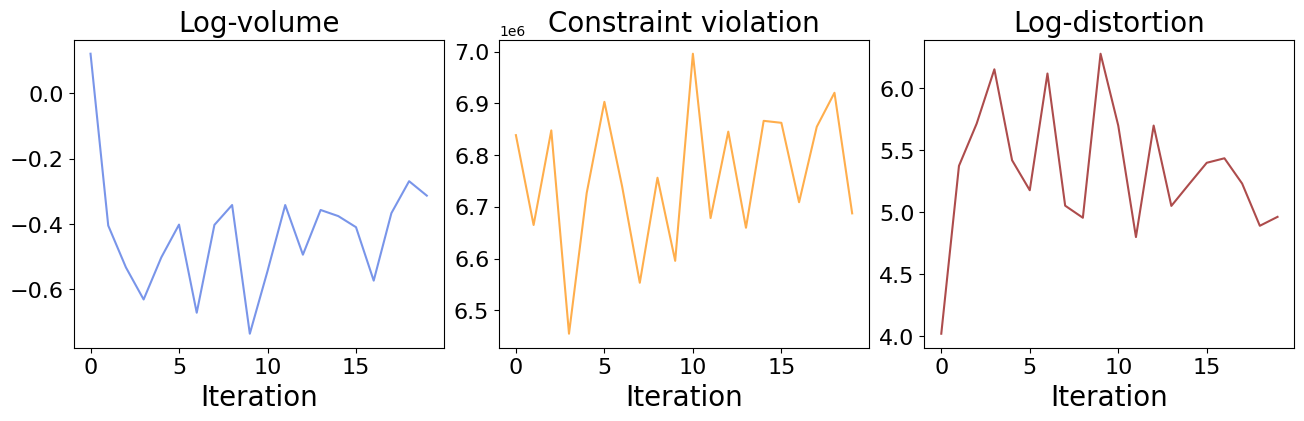

In [13]:
run_instance(args)